# Generate the Gabor library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from wavelet_utils import makeGaborFilter_visual, make_and_save_FilterLibrary, makeFilterParamDict, loadFilterParamDict

## Parameters

In [2]:
full_screen_coverage = [-90, 0, -45, 45] # [az_left, az_right, el_bottom, el_top] full screen position in visual degrees
visual_coverage = [-90, 0, -30, 30] # [az_left, az_right, el_bottom, el_top] screen coverage in visual degrees (seen by the animal)

screen_x = 100 # horizontal screen size in pixels for the Gabor filter generation and movie analysis

nx = 40 # number of Gabor filters in the horizontal direction (azimuth) (y will be generated)
        # 40 is a good number. Use 5 for testing to make it fast
        
n_thetas = 8 # number of angles to generate

size_min = 3 # minimum size in visual degrees
size_max = 14 # maximum size in visual degrees
n_sizes = 5   # number of sizes to generate

freq_min = .02 # minimum frequency in cycles per visual degree
freq_max = .1 # maximum frequency in cycles per visual degree
n_freqs = 4  # number of frequencies to generate

n_phases = 4  # number of phases to generate


In [3]:
#calculations
az_left, az_right, el_bottom, el_top = visual_coverage

screen_y = int(screen_x * (el_top - el_bottom) / (az_right - az_left))
ny = int(nx * (el_top - el_bottom) / (az_right - az_left))

# centers in visual degrees
x_steps = np.linspace(az_left, az_right, nx, endpoint=False)+(az_right - az_left) / (2*nx)
y_steps = np.linspace(el_bottom, el_top, ny, endpoint=False)+(el_top - el_bottom) / (2*ny)

angles= np.linspace(0, np.pi, n_thetas, endpoint=False)
sizes = np.logspace(np.log10(size_min), np.log10(size_max), n_sizes)
freqs = np.logspace(np.log10(freq_min), np.log10(freq_max), n_freqs)
phases = np.linspace(0,  2 * np.pi, n_phases, endpoint=False)

print(f"Screen size: {screen_x}x{screen_y} pixels")
print(f"Full screen coverage: {full_screen_coverage} degrees")
print(f"Visual coverage: {visual_coverage} degrees")
print(f"Center positions (x_deg): {np.round(x_steps, 1)} degrees")
print(f"Center positions (y_deg): {np.round(y_steps, 1)} degrees")
print(f"Angles (degrees): {np.round(np.rad2deg(angles), 1)}")
print(f"Sizes (degrees): {sizes}")
print(f"Frequencies (cycles/degree): {freqs}")
print(f"Phases (degrees): {np.rad2deg(phases)}")


Screen size: 100x66 pixels
Full screen coverage: [-90, 0, -45, 45] degrees
Visual coverage: [-90, 0, -30, 30] degrees
Center positions (x_deg): [-88.9 -86.6 -84.4 -82.1 -79.9 -77.6 -75.4 -73.1 -70.9 -68.6 -66.4 -64.1
 -61.9 -59.6 -57.4 -55.1 -52.9 -50.6 -48.4 -46.1 -43.9 -41.6 -39.4 -37.1
 -34.9 -32.6 -30.4 -28.1 -25.9 -23.6 -21.4 -19.1 -16.9 -14.6 -12.4 -10.1
  -7.9  -5.6  -3.4  -1.1] degrees
Center positions (y_deg): [-28.8 -26.5 -24.2 -21.9 -19.6 -17.3 -15.  -12.7 -10.4  -8.1  -5.8  -3.5
  -1.2   1.2   3.5   5.8   8.1  10.4  12.7  15.   17.3  19.6  21.9  24.2
  26.5  28.8] degrees
Angles (degrees): [  0.   22.5  45.   67.5  90.  112.5 135.  157.5]
Sizes (degrees): [ 3.          4.40933352  6.4807407   9.52524907 14.        ]
Frequencies (cycles/degree): [0.02       0.03419952 0.05848035 0.1       ]
Phases (degrees): [  0.  90. 180. 270.]


In [4]:
total_n=len(sizes)*len(angles)*len(freqs)*len(phases)*len(x_steps)*len(y_steps)
print(f"Total number of Gabor filters to generate: {total_n}")

Total number of Gabor filters to generate: 665600


In [5]:
# a control
gabor_step=(az_right-az_left)/nx 
print(f"Control: Gabor placement step in visual degrees (x): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees. {'OK' if (gabor_step < size_min) else 'WARNING!'}")
gabor_step=(el_top-el_bottom)/ny
print(f"Control: Gabor placement step in visual degrees (y): {gabor_step:.1f}, vs size_min: {size_min:.1f} degrees. {'OK' if (gabor_step < size_min) else 'WARNING!'}")
visual_step_x=(az_right-az_left)/screen_x
print(f"Control: Gabor resolution in visual degrees (x): {visual_step_x:.1f}, vs 1/freq_max: {1/freq_max:.1f} degrees. {'OK' if (visual_step_x < 1/freq_max/4) else 'WARNING!'}")
visual_step_y=(el_top-el_bottom)/screen_y
print(f"Control: Gabor resolution in visual degrees (y): {visual_step_y:.1f}, vs 1/freq_max: {1/freq_max:.1f} degrees. {'OK' if (visual_step_y < 1/freq_max/4) else 'WARNING!'}")


Control: Gabor placement step in visual degrees (x): 2.2, vs size_min: 3.0 degrees. OK
Control: Gabor placement step in visual degrees (y): 2.3, vs size_min: 3.0 degrees. OK
Control: Gabor resolution in visual degrees (x): 0.9, vs 1/freq_max: 10.0 degrees. OK
Control: Gabor resolution in visual degrees (y): 0.9, vs 1/freq_max: 10.0 degrees. OK


## Do the generation

In [6]:

path = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'

# pack parameters into a dictionary 
params=makeFilterParamDict(screen_x, screen_y, visual_coverage, full_screen_coverage, x_steps, y_steps, angles, sizes, freqs, phases)

# generate and save the filter library if it doesn't exist
lib_path, sidecar_path = make_and_save_FilterLibrary(path, params, force=True)

Generating Gabor filter library...


100%|██████████| 40/40 [01:03<00:00,  1.58s/it]


Done. Library shape: (40, 26, 8, 5, 4, 4, 100, 66)
Library saved to D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_40_26_8_5_4_4.npy and D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_40_26_8_5_4_4.json


## Testing: loading and displaying the library

In [7]:
library = np.load(lib_path)
print(f"Loaded Gabor filter library from {lib_path} with shape {library.shape}")

# load the parameters from the sidecar JSON file
xs, ys, angles, sizes, freqs, phases, visual_coverage, full_screen_coverage, screen_x, screen_y = loadFilterParamDict(sidecar_path)

Loaded Gabor filter library from D:\SynologyDriveSyncedDATA\PROCESSED\Waven\gaborLibrary_40_26_8_5_4_4.npy with shape (40, 26, 8, 5, 4, 4, 100, 66)


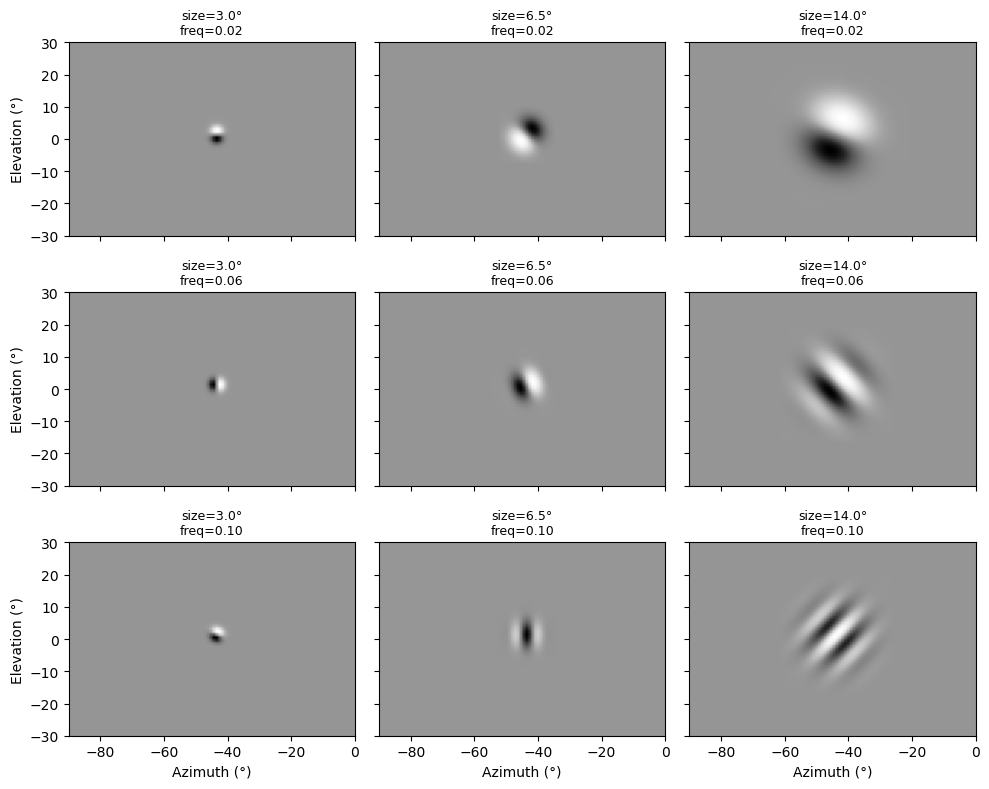

In [8]:
# Displaying range of gabor filters in the library
az_left, az_right, el_bottom, el_top = visual_coverage

# center index in library grid
i = len(xs) // 2
j = len(ys) // 2

sizeis = [0, len(sizes)//2, len(sizes)-1]
freqis = [0, len(freqs)//2, len(freqs)-1]

fig, axes = plt.subplots(
    len(freqis),
    len(sizeis),
    figsize=(10, 8),
    sharex=True,
    sharey=True
)

for row, freqi in enumerate(freqis):
    for col, sizei in enumerate(sizeis):
        anglei = np.random.randint(0, len(angles))
        phasei = np.random.randint(0, len(phases))

        filt = library[i, j, anglei, sizei, freqi, phasei, :, :]

        ax = axes[row, col]

        v = np.max(np.abs(filt))

        ax.imshow(
            filt.T,
            cmap="Greys",
            vmin=-v,
            vmax=v,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto"
        )

        ax.set_title(
            f"size={sizes[sizei]:.1f}°\nfreq={freqs[freqi]:.2f}",
            fontsize=9
        )

        if row == len(freqis) - 1:
            ax.set_xlabel("Azimuth (°)")
        if col == 0:
            ax.set_ylabel("Elevation (°)")

plt.tight_layout()
plt.show()

In [9]:
# Display an interactive widget to explore the filter library
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

az_left, az_right, el_bottom, el_top = visual_coverage

# parameter arrays in same order as library dimensions
param_names = ["x", "y", "angle", "size", "freq", "phase"]
param_values = [xs, ys, angles, sizes, freqs, phases]

sliders = [
    widgets.IntSlider(
        value=len(vals)//2,
        min=0,
        max=len(vals)-1,
        step=1,
        description=name,
        continuous_update=False
    )
    for name, vals in zip(param_names, param_values)
]

out = widgets.Output()

def plot_filter(*args):
    with out:
        out.clear_output(wait=True)

        xi, yi, anglei, sizei, freqi, phasei = [s.value for s in sliders]

        filt = library[xi, yi, anglei, sizei, freqi, phasei, :, :]

        v = np.max(np.abs(filt))
        if v == 0:
            v = 1

        plt.figure(figsize=(6, 4))
        plt.imshow(
            filt.T,
            cmap="Greys",
            vmin=-v,
            vmax=v,
            extent=[az_left, az_right, el_bottom, el_top],
            origin="lower",
            aspect="auto"
        )

        plt.xlabel("Azimuth (°)")
        plt.ylabel("Elevation (°)")

        title = (
            f"x={xs[xi]:.2f}, y={ys[yi]:.2f}, "
            f"angle={angles[anglei]:.2f}, "
            f"size={sizes[sizei]:.2f}, "
            f"freq={freqs[freqi]:.3f}, "
            f"phase={phases[phasei]:.2f}"
        )
        plt.title(title, fontsize=10)

        plt.tight_layout()
        plt.show()

for s in sliders:
    s.observe(plot_filter, names="value")

display(widgets.VBox(sliders), out)
plot_filter()

Output()